# 2_angry_mob_gpu1
training our tuning fork networks, setting to use gpu1 to avoid memory conflict with other notebooks needing gpu allocation

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-02-27 14:40:56.795517: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-27 14:40:56.795546: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-27 14:40:56.796580: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-27 14:40:56.802767: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-27 14:40:57.385683: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-02-27 14:40:57.914551: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18447 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


## data prep
load in data and perform final prep (normalisation, label definition) before we start training)

In [2]:
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/barbie_nu.h5', key='df')

#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.95, random_state=seed)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.05, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  1047696
Validation set:  55142


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std,log_nu_0_41_std,log_nu_0_42_std,log_nu_0_43_std,log_nu_0_44_std,log_nu_0_45_std
count,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,...,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06
mean,1.018413e+00,1.576475e-02,2.782837e-01,1.800447e+00,4.628984e+00,1.132672e+00,1.811612e+00,6.040085e+03,1.364829e-02,2.695808e+03,...,6.778618e-15,-2.855876e-15,1.653083e-15,4.966201e-15,7.047146e-16,7.653635e-15,-2.083393e-15,4.996951e-15,2.264860e-15,-4.464009e-15
std,1.188714e-01,1.314553e-02,2.294834e-02,1.153523e-01,3.492387e+00,2.576956e-01,1.362638e+00,6.644132e+02,1.252237e-02,9.594349e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,7.000000e-01,1.241437e-03,2.400195e-01,1.600098e+00,1.865560e-02,6.006561e-01,2.575467e-01,4.663410e+03,9.960149e-05,7.069718e+02,...,-3.256371e+00,-3.256499e+00,-3.256724e+00,-3.256984e+00,-3.257242e+00,-3.257479e+00,-3.257698e+00,-3.257904e+00,-3.258101e+00,-3.258289e+00
25%,9.330000e-01,4.428834e-03,2.583105e-01,1.700684e+00,1.798067e+00,9.507823e-01,8.449202e-01,5.545393e+03,2.653046e-03,1.978679e+03,...,-6.128663e-01,-6.127785e-01,-6.126330e-01,-6.124484e-01,-6.122666e-01,-6.121199e-01,-6.119341e-01,-6.117809e-01,-6.116612e-01,-6.114950e-01
50%,1.035000e+00,1.159459e-02,2.773438e-01,1.800146e+00,3.836663e+00,1.088573e+00,1.414103e+00,5.952699e+03,9.949250e-03,2.654218e+03,...,1.245599e-01,1.246725e-01,1.248018e-01,1.249217e-01,1.250079e-01,1.250797e-01,1.251489e-01,1.252120e-01,1.252990e-01,1.254035e-01
75%,1.116000e+00,2.475267e-02,2.978125e-01,1.900488e+00,6.870449e+00,1.264503e+00,2.353924e+00,6.415778e+03,2.235996e-02,3.367139e+03,...,7.340587e-01,7.339929e-01,7.338441e-01,7.337370e-01,7.336355e-01,7.335394e-01,7.334309e-01,7.333475e-01,7.332500e-01,7.331606e-01
max,1.200000e+00,5.053113e-02,3.199902e-01,1.999951e+00,1.399994e+01,2.117572e+00,1.547402e+01,8.882541e+03,5.051477e-02,6.181659e+03,...,2.499163e+00,2.499528e+00,2.499303e+00,2.499460e+00,2.499623e+00,2.499766e+00,2.499893e+00,2.500011e+00,2.500124e+00,2.500231e+00


## pca
here's where I define pca components that are required to save our networks (they construct the inversePCA layer)

this is a nice time to do a comparison on how much including the classical observables in the pca process affects how many components we need to include for a reasonable level of explained variance!

Explained variance ratio with n_comps = 1 is 0.6972191254310829
Explained variance ratio with n_comps = 2 is 0.9850287763982981
Explained variance ratio with n_comps = 3 is 0.9999999999999999
Explained variance ratio with n_comps = 1 is 0.9999816607684866
Explained variance ratio with n_comps = 2 is 0.9999992233281435
Explained variance ratio with n_comps = 3 is 0.9999997419112074


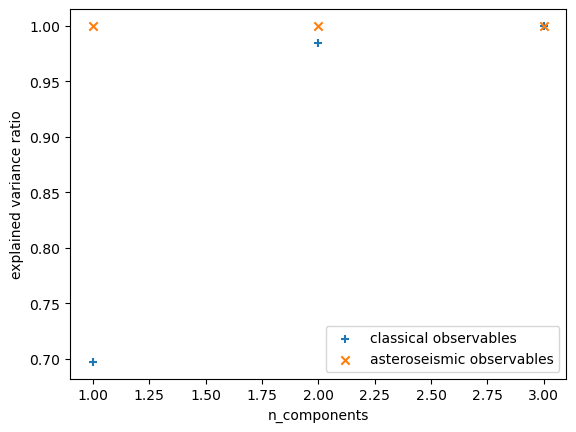

In [7]:
"""
pca comparison
"""
###### classical outs
### define pca global vars
df_outs = df_full[classical_outputs]
seed = 42

### arrays for plot loop
classical_evr_arr = np.zeros(len(classical_outputs))
n_arr = np.arange(1,len(classical_outputs)+1)

### plot loop
i=0
for n in n_arr:
    n_components = n
    pca = PCA(n_components=n_components, random_state=seed)
    pca.fit(df_outs)
    print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))
    classical_evr_arr[i] = sum(pca.explained_variance_ratio_)
    i+=1

###### astero_outs
### define pca global vars
df_outs = df_full[astero_outputs]

### arrays for plot loop
astero_evr_arr = np.zeros(len(classical_outputs))

### plot loop
i=0
for n in n_arr:
    n_components = n
    pca = PCA(n_components=n_components, random_state=seed)
    pca.fit(df_outs)
    print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))
    astero_evr_arr[i] = sum(pca.explained_variance_ratio_)
    i+=1
    
plt.scatter(n_arr, classical_evr_arr, marker='+', label='classical observables')
plt.scatter(n_arr, astero_evr_arr, marker='x',label='asteroseismic observables')
plt.ylabel('explained variance ratio')
plt.xlabel('n_components')
plt.legend()

In [3]:
"""
pca
"""
#### define pca global vars
n_components = 5
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 5 is 0.9999999738098696


In [4]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array([0.01, 0.02, 0.001,0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] / df_full[["radius", "luminosity", "surface_Z"] + [f'nu_0_{i+1}' for i in range(14,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity", "log_surface_Z"] + [f'log_nu_0_{i+1}' for i in range(14,25)]].std()


weights = log_weights.values.tolist()

print(weights)

[0.0404396032697295, 0.01593228797007494, 0.04452107630433814, 0.00016667030242831007, 0.00015733933591581152, 0.0001491147982946965, 0.00014175098532282846, 0.00013505912143240066, 0.000128934434739406, 0.0001233175056851056, 0.00011815420774364464, 0.00011339103527327905, 0.00010897713404833435, 0.00010486947466103136]


## gridsearch parameters
define gridsearch parameters for the tuning/pitchfork setup, focus on hparams that alter overarching architecture

In [5]:
"""
DEFINE TARGET ARCHITECTURES FOR GRID SEARCH
Rerun after training to avoid "___ not iterable" errors
"""
stem_d_layers = [4]
stem_d_units = [64]

ctine_d_layers = [6]
ctine_d_units = [64]

atine_d_layers = [6]
atine_d_units = [256]

archs = pd.DataFrame(product(stem_d_layers, stem_d_units, ctine_d_layers, ctine_d_units, atine_d_layers, atine_d_units))

archs.columns = ['stem_d_layers', 'stem_d_units', 'ctine_d_layers', 'ctine_d_units', 'atine_d_layers', 'atine_d_units']

In [ ]:
"""
        ________
_______/
       \________
| stem | tines |

"""


tf.keras.backend.clear_session()

for i in range(500,1000):
    for arch_i in range(len(archs)):
        tf.keras.backend.clear_session()
        arch = archs.iloc[[arch_i]]
        
        ######## stem
        #### input
        stem_input = keras.Input(shape=(len(inputs),))
    
        #### dense layers
        stem_d_layers = arch["stem_d_layers"].iloc[0]
        stem_d_units = arch["stem_d_units"].iloc[0]
    
        for stem_d_layer in range(stem_d_layers):
            if stem_d_layer == 0:
                stem = layers.Dense(stem_d_units, activation='relu')(stem_input)
                stem = layers.LayerNormalization()(stem)
            else:
                stem = layers.Dense(stem_d_units, activation='relu')(stem)
                stem = layers.LayerNormalization()(stem)
    
        ######## classical tine
        #### dense layers
        ctine_d_layers = arch["ctine_d_layers"].iloc[0]
        ctine_d_units = arch["ctine_d_units"].iloc[0]
    
        for ctine_d_layer in range(ctine_d_layers):
            if ctine_d_layer == 0:
                ctine = layers.Dense(ctine_d_units, activation='relu')(stem)
                ctine = layers.LayerNormalization()(ctine)
            else:
                ctine = layers.Dense(ctine_d_units, activation='relu')(ctine)
                ctine = layers.LayerNormalization()(ctine)
    
        #### output
        ctine_out = layers.Dense(len(classical_outputs),name='classical_outs')(ctine)
    
    
        ######## astero tine
        #### dense layers
        atine_d_layers = arch["atine_d_layers"].iloc[0]
        atine_d_units = arch["atine_d_units"].iloc[0]
        
        for atine_d_layer in range(atine_d_layers):
            if atine_d_layer == 0:
                atine = layers.Dense(atine_d_units, activation='relu')(stem)
                atine = layers.LayerNormalization()(atine)
            else:
                atine = layers.Dense(atine_d_units, activation='relu')(atine)
                atine = layers.LayerNormalization()(atine)
    
        #### output
        atine = layers.Dense(int(len(pca.components_)))(atine)
        atine_out = InversePCA(pca_comps = pca.components_, pca_mean = pca.mean_, name='asteroseismic_outs')(atine)
    
        ######## construct and fit
        model = keras.Model(inputs=stem_input, outputs=[ctine_out, atine_out], name='tuning_fork')
    
        #### compile model
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    
            
        model.compile(loss=[WMSE(weights[:3]), WMSE(weights[3:])], optimizer=optimizer)
        
        #### fit model
        arch_name = "barbie_pitchfork_"+str(i)
    
        log_dir = "/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/logs/barbie/" + arch_name
    
        def scheduler(epoch, lr):
            if lr < 5e-6:
                return lr
            else:
                return lr * tf.math.exp(-0.1)
    
        lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)
                                                           
        cp_callback = tf.keras.callbacks.ModelCheckpoint("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/barbie/" + arch_name + ".h5",
                                                         monitor= 'val_loss',
                                                         save_best_only= True,
                                                         save_freq='epoch')    
    
        tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir) 
    
        history = model.fit(df_train_inputs,
                            [df_train_outputs[classical_outputs],df_train_outputs[astero_outputs]],
                            validation_data=(df_val_inputs,[df_val_outputs[classical_outputs], df_val_outputs[astero_outputs]]),
                            batch_size=2**14,
                            verbose=1,
                            epochs=50,
                            callbacks=[lr_callback, cp_callback, tb_callback],
                            shuffle=True
                           )  

2024-02-27 14:41:29.080130: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Epoch 1/50


2024-02-27 14:41:31.988737: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-02-27 14:41:32.137169: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f5465422120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-27 14:41:32.137191: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4500, Compute Capability 8.6
2024-02-27 14:41:32.141128: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1709044892.215823 1310264 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 [==============================] - 7s 32ms/step - loss: 38532552.0000 - classical_outs_loss: 560.2303 - inverse_pca_loss: 38532004.0000 - val_loss: 5704751.0000 - val_classical_outs_loss: 140.5732 - val_inverse_pca_loss: 5704610.5000 - lr: 0.0090
Epoch 2/50
 4/64 [>.............................] - ETA: 1s - loss: 5400910.0000 - classical_outs_loss: 135.1432 - inverse_pca_loss: 5400775.0000

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


...

64/64 [==============================] - 2s 26ms/step - loss: 2731332.0000 - classical_outs_loss: 115.4913 - inverse_pca_loss: 2731215.7500 - val_loss: 1009470.4375 - val_classical_outs_loss: 67.4861 - val_inverse_pca_loss: 1009402.8750 - lr: 0.0082
Epoch 3/50
64/64 [==============================] - 2s 26ms/step - loss: 685141.1250 - classical_outs_loss: 46.8159 - inverse_pca_loss: 685094.3125 - val_loss: 492200.4062 - val_classical_outs_loss: 36.9388 - val_inverse_pca_loss: 492163.5312 - lr: 0.0074
Epoch 4/50
64/64 [==============================] - 2s 26ms/step - loss: 427316.6562 - classical_outs_loss: 32.5897 - inverse_pca_loss: 427283.9375 - val_loss: 357891.0312 - val_classical_outs_loss: 28.8440 - val_inverse_pca_loss: 357862.2188 - lr: 0.0067
Epoch 5/50
64/64 [==============================] - 2s 26ms/step - loss: 317033.5000 - classical_outs_loss: 26.0157 - inverse_pca_loss: 317007.5312 - val_loss: 269423.4062 - val_classical_outs_loss: 22.8702 - val_inverse_pca_loss: 269400.

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


64/64 [==============================] - 2s 26ms/step - loss: 4540888.0000 - classical_outs_loss: 157.4044 - inverse_pca_loss: 4540728.5000 - val_loss: 1881975.5000 - val_classical_outs_loss: 103.6466 - val_inverse_pca_loss: 1881872.0000 - lr: 0.0082
Epoch 3/50
64/64 [==============================] - 2s 26ms/step - loss: 1120248.0000 - classical_outs_loss: 67.1554 - inverse_pca_loss: 1120180.6250 - val_loss: 617124.8125 - val_classical_outs_loss: 42.5145 - val_inverse_pca_loss: 617082.3125 - lr: 0.0074
Epoch 4/50
64/64 [==============================] - 2s 26ms/step - loss: 542861.3125 - classical_outs_loss: 35.1858 - inverse_pca_loss: 542826.0625 - val_loss: 424791.2188 - val_classical_outs_loss: 26.6471 - val_inverse_pca_loss: 424764.5938 - lr: 0.0067
Epoch 5/50
64/64 [==============================] - 2s 26ms/step - loss: 428624.9062 - classical_outs_loss: 26.5414 - inverse_pca_loss: 428598.3125 - val_loss: 360142.2500 - val_classical_outs_loss: 25.5420 - val_inverse_pca_loss: 3601

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


64/64 [==============================] - 2s 26ms/step - loss: 2402543.7500 - classical_outs_loss: 119.6441 - inverse_pca_loss: 2402425.2500 - val_loss: 1180367.7500 - val_classical_outs_loss: 67.9669 - val_inverse_pca_loss: 1180299.8750 - lr: 0.0082
Epoch 3/50
64/64 [==============================] - 2s 26ms/step - loss: 942791.9375 - classical_outs_loss: 54.2120 - inverse_pca_loss: 942737.7500 - val_loss: 672415.8750 - val_classical_outs_loss: 42.6869 - val_inverse_pca_loss: 672373.1875 - lr: 0.0074
Epoch 4/50
64/64 [==============================] - 2s 27ms/step - loss: 752485.2500 - classical_outs_loss: 44.5097 - inverse_pca_loss: 752440.8750 - val_loss: 651032.6250 - val_classical_outs_loss: 36.2029 - val_inverse_pca_loss: 650996.4375 - lr: 0.0067
Epoch 5/50
64/64 [==============================] - 2s 25ms/step - loss: 405722.3438 - classical_outs_loss: 32.5051 - inverse_pca_loss: 405689.8438 - val_loss: 339962.4062 - val_classical_outs_loss: 28.8194 - val_inverse_pca_loss: 339933.